In [3]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
import requests
import pandas as pd

drug = "ibuprofen"

url = (
    "https://api.fda.gov/drug/event.json"
    "?search=patient.drug.medicinalproduct:"
    + drug
    + "&limit=100"
)

response = requests.get(url)

print("Status code:", response.status_code)

data = response.json()

print("Number of reports downloaded:", len(data["results"]))

Status code: 200
Number of reports downloaded: 100


In [4]:
# Convert FDA reports into a simple table

reports = data["results"]

rows = []

for report in reports:
    patient = report.get("patient", {})

    age = patient.get("patientonsetage")
    sex = patient.get("patientsex")

    reactions = patient.get("reaction", [])

    for reaction in reactions:
        rows.append({
            "age": age,
            "sex": sex,
            "reaction": reaction.get("reactionmeddrapt")
        })

df = pd.DataFrame(rows)

print("Total reaction records:", len(df))
df.head()

Total reaction records: 457


,age,sex,reaction
0,None,2,Dyspepsia
1,None,2,Renal impairment
2,46,2,Cholecystectomy
3,46,2,Nephrolithiasis
4,46,2,Biliary tract disorder


In [5]:
# Clean and prepare the dataset

df = df.dropna(subset=["reaction"])

df["reaction"] = df["reaction"].str.strip().str.title()

print("Unique adverse-event terms:", df["reaction"].nunique())
print("Clean records:", len(df))

df.head()

Unique adverse-event terms: 261
Clean records: 457


,age,sex,reaction
0,None,2,Dyspepsia
1,None,2,Renal Impairment
2,46,2,Cholecystectomy
3,46,2,Nephrolithiasis
4,46,2,Biliary Tract Disorder


In [6]:
# Find the most frequently reported adverse events

top_events = df["reaction"].value_counts().head(15)

print(top_events)

reaction
Pain                    15
Malaise                  9
Weight Decreased         8
Injury                   7
Dyspnoea                 7
Abdominal Pain           6
Deep Vein Thrombosis     6
Emotional Distress       5
Uterine Perforation      5
Depression               5
Fatigue                  5
Diarrhoea                5
Anxiety                  4
Erythema                 4
Blister                  4
Name: count, dtype: int64


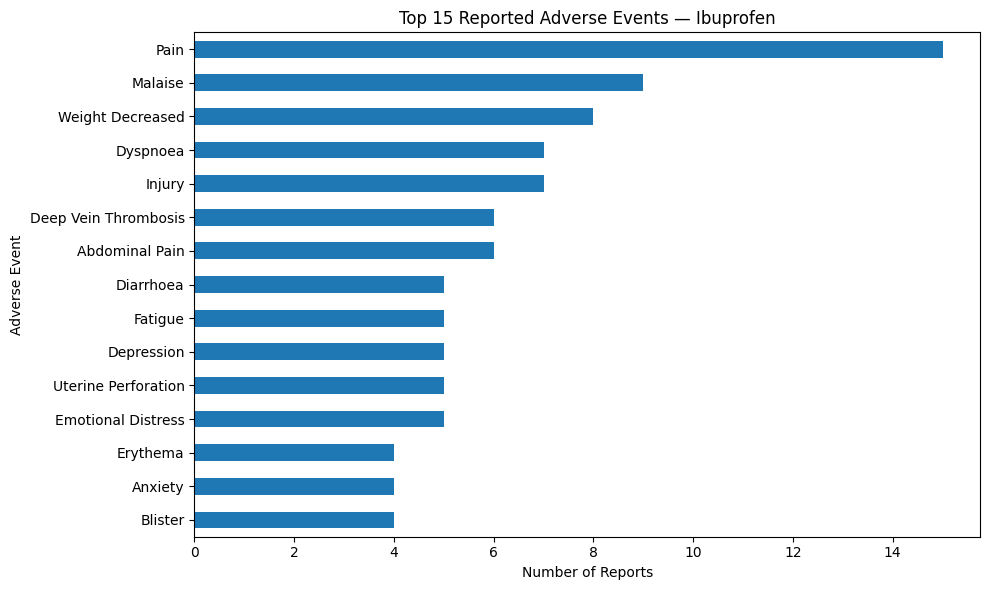

In [7]:
# Visualize the top 15 reported adverse events

plt.figure(figsize=(10, 6))

top_events.sort_values().plot(kind="barh")

plt.title("Top 15 Reported Adverse Events — Ibuprofen")
plt.xlabel("Number of Reports")
plt.ylabel("Adverse Event")

plt.tight_layout()
plt.show()

In [9]:
# Convert age to numeric
df["age"] = pd.to_numeric(df["age"], errors="coerce")

age_df = df.dropna(subset=["age"]).copy()

# FDA age is often reported in years for this dataset
age_df = age_df[(age_df["age"] >= 0) & (age_df["age"] <= 120)]

print("Reports with usable age:", len(age_df))
print("Median reported age:", age_df["age"].median())

Reports with usable age: 398
Median reported age: 31.0


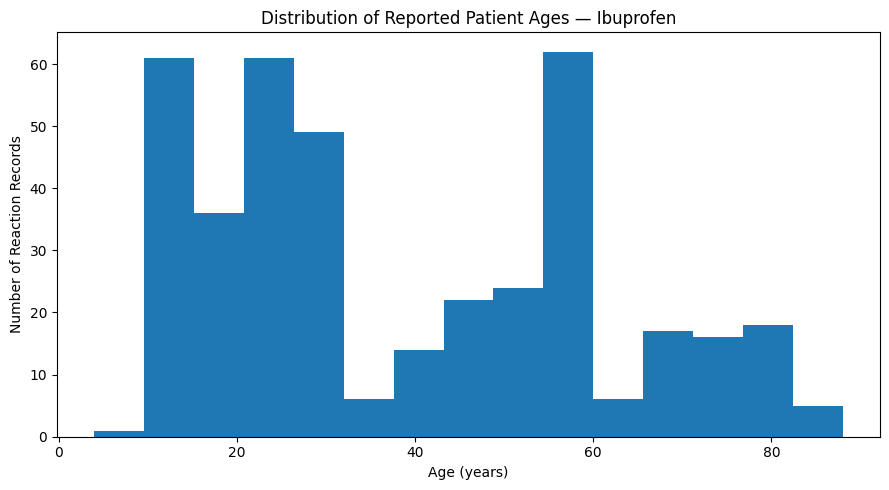

In [10]:
plt.figure(figsize=(9, 5))

plt.hist(age_df["age"], bins=15)

plt.title("Distribution of Reported Patient Ages — Ibuprofen")
plt.xlabel("Age (years)")
plt.ylabel("Number of Reaction Records")

plt.tight_layout()
plt.show()

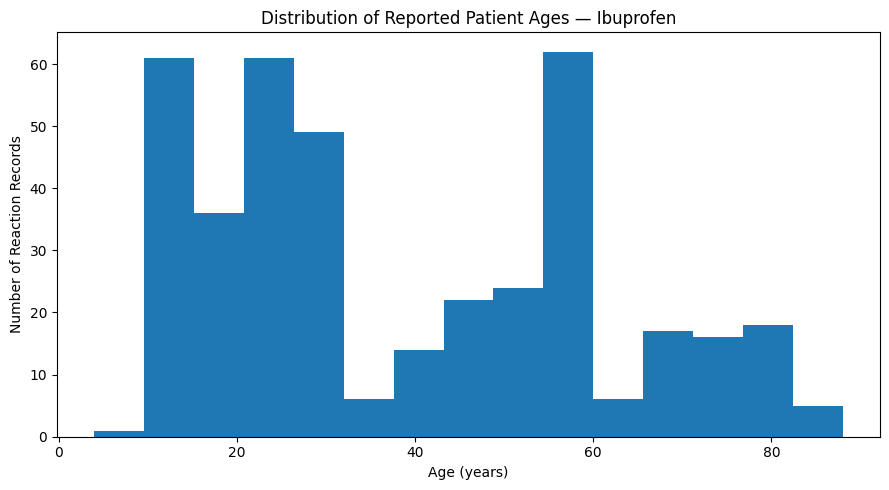

In [11]:
plt.figure(figsize=(9, 5))

plt.hist(age_df["age"], bins=15)

plt.title("Distribution of Reported Patient Ages — Ibuprofen")
plt.xlabel("Age (years)")
plt.ylabel("Number of Reaction Records")

plt.tight_layout()
plt.show()

In [12]:
sex_labels = {
    "1": "Male",
    "2": "Female",
    "0": "Unknown/Unspecified"
}

sex_counts = (
    df["sex"]
    .fillna("0")
    .astype(str)
    .map(lambda x: sex_labels.get(x, "Unknown/Unspecified"))
    .value_counts()
)

print(sex_counts)

sex
Female                 302
Male                   152
Unknown/Unspecified      3
Name: count, dtype: int64


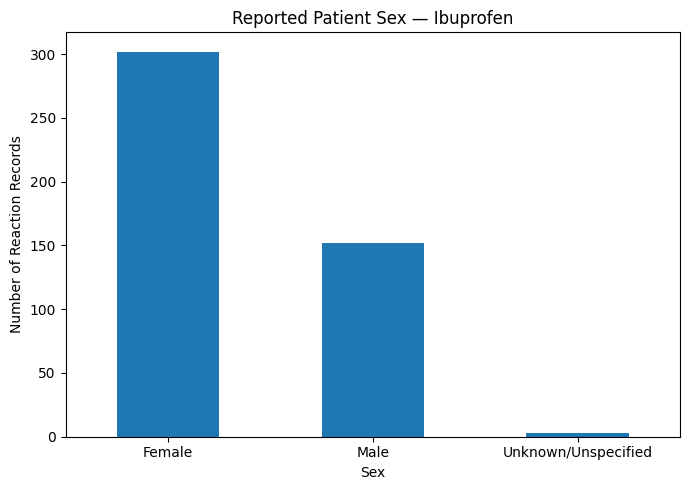

In [13]:
plt.figure(figsize=(7, 5))

sex_counts.plot(kind="bar")

plt.title("Reported Patient Sex — Ibuprofen")
plt.xlabel("Sex")
plt.ylabel("Number of Reaction Records")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [14]:
print("========== PHARMACOVIGILANCE SUMMARY ==========")

print(f"Drug analyzed: {drug}")
print(f"Reaction records analyzed: {len(df)}")
print(f"Unique adverse-event terms: {df['reaction'].nunique()}")

print("\nTop 10 reported adverse events:")
for event, count in df["reaction"].value_counts().head(10).items():
    print(f"- {event}: {count}")

print("\nReported patient age:")
print(f"- Median age: {age_df['age'].median():.1f} years")
print(f"- Age range: {age_df['age'].min():.0f}–{age_df['age'].max():.0f} years")

print("\nReported sex distribution:")
print(sex_counts)

========== PHARMACOVIGILANCE SUMMARY ==========
Drug analyzed: ibuprofen
Reaction records analyzed: 457
Unique adverse-event terms: 261

Top 10 reported adverse events:
- Pain: 15
- Malaise: 9
- Weight Decreased: 8
- Injury: 7
- Dyspnoea: 7
- Abdominal Pain: 6
- Deep Vein Thrombosis: 6
- Emotional Distress: 5
- Uterine Perforation: 5
- Depression: 5

Reported patient age:
- Median age: 31.0 years
- Age range: 4–88 years

Reported sex distribution:
sex
Female                 302
Male                   152
Unknown/Unspecified      3
Name: count, dtype: int64


In [15]:
limitations = """
LIMITATIONS

1. FDA adverse-event reports are spontaneous reports and do not represent
   all adverse events occurring in the population.

2. A reported event does not establish that the drug caused the event.

3. Reporting may be affected by under-reporting, duplicate reports,
   reporting bias, and missing patient information.

4. This project is descriptive and is not a causal or clinical risk assessment.
"""

print(limitations)


LIMITATIONS

1. FDA adverse-event reports are spontaneous reports and do not represent
   all adverse events occurring in the population.

2. A reported event does not establish that the drug caused the event.

3. Reporting may be affected by under-reporting, duplicate reports,
   reporting bias, and missing patient information.

4. This project is descriptive and is not a causal or clinical risk assessment.



In [16]:
project_summary = """
PROJECT SUMMARY

Drug Adverse-Event Signal Explorer is a Python-based pharmacovigilance
data-analysis project using publicly available FDA adverse-event reports.

The project demonstrates:
• API-based healthcare data retrieval
• Data cleaning and preprocessing
• Adverse-event frequency analysis
• Patient age and sex exploration
• Data visualization
• Interpretation of spontaneous-report data
• Recognition of pharmacovigilance data limitations
"""

print(project_summary)


PROJECT SUMMARY

Drug Adverse-Event Signal Explorer is a Python-based pharmacovigilance
data-analysis project using publicly available FDA adverse-event reports.

The project demonstrates:
• API-based healthcare data retrieval
• Data cleaning and preprocessing
• Adverse-event frequency analysis
• Patient age and sex exploration
• Data visualization
• Interpretation of spontaneous-report data
• Recognition of pharmacovigilance data limitations

